<a href="https://colab.research.google.com/github/wolfridercraze2903-tech/fghfhbfhb/blob/main/notebooks/Exercise_4_Quantum_Error_Correction_Bit_Flip.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GENCYS 2.0 - Exercise No. 4

# Quantum Error Correction, Part 1: Bit-Flip Errors

### Qiskit 2.5.2 - Google Colab Notebook

Quantum information is fragile: noise can accidentally apply an $X$ gate and turn $|0\rangle$ into $|1\rangle$, or $|1\rangle$ into $|0\rangle$.

In this exercise, we will:

- understand why quantum error correction does **not** clone a qubit
- encode one logical qubit across three physical qubits
- inject a single bit-flip ($X$) error
- learn how a syndrome identifies where an error happened
- recover the original state without measuring it
- verify the result using measurements and state fidelity

> This is the first of two progressive error-correction notebooks. It handles **bit-flip errors only**.

## Why Does the No-Cloning Theorem Not Stop Us?

Classically, we can protect a bit by making copies:

```text
0  ->  000
1  ->  111
```

But an **unknown** quantum state cannot be copied. If

$$
|\psi\rangle = \alpha|0\rangle + \beta|1\rangle,
$$

quantum error correction does **not** create three independent copies $|\psi\rangle|\psi\rangle|\psi\rangle$. Instead, two CNOT gates distribute the information into correlations:

$$
|\psi\rangle|00\rangle
\longrightarrow
\alpha|000\rangle + \beta|111\rangle.
$$

This is one **entangled encoded state**, not three clones. The amplitudes $\alpha$ and $\beta$ are stored nonlocally across the three qubits.

## The Three-Qubit Repetition Code

We call qubit 0 the **data qubit** and qubits 1 and 2 the **helper qubits**.

The encoding is:

```text
data q0:   |psi> ---●---●---
                  |   |
helper q1: |0> ---X---|---
                      |
helper q2: |0> -------X---
```

For basis states, this gives:

$$|0\rangle \rightarrow |000\rangle, \qquad |1\rangle \rightarrow |111\rangle.$$

By linearity, it also works for every superposition $\alpha|0\rangle+\beta|1\rangle$.

## Install Qiskit

Run this cell first in Google Colab. It installs the same Qiskit versions used by the other GENCYS exercises.

In [1]:
!pip install -q "qiskit==2.5.2" "qiskit-aer~=0.17" pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 2.5 MB/s eta 0:00:00


## Import Qiskit and Check the Version

In [2]:
import qiskit
import qiskit_aer

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, partial_trace, state_fidelity
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

print("Qiskit version:", qiskit.__version__)
print("Qiskit Aer version:", qiskit_aer.__version__)

Qiskit version: 2.5.2
Qiskit Aer version: 0.17.2


## Build the Encoder

The function below adds the two encoding CNOT gates to any three-qubit circuit. The data qubit may contain an arbitrary state before we call it.

In [3]:
def encode_bit_flip(circuit):
    # Spread the data qubit's information into three-qubit correlations.
    circuit.cx(0, 1)
    circuit.cx(0, 2)

## Encode a Superposition

Let us encode

$$|+\rangle = \frac{|0\rangle+|1\rangle}{\sqrt{2}}.$$

Using $|+\rangle$ is more informative than checking only classical-looking states: it lets us confirm that the circuit preserves quantum coherence, not merely a 0 or 1.

Non-zero encoded amplitudes:
{np.str_('000'): np.complex128(0.7071067811865475+0j), np.str_('111'): np.complex128(0.7071067811865475+0j)}


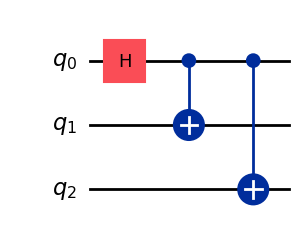

In [4]:
encoded_plus = QuantumCircuit(3)

# Prepare |+> on the data qubit.
encoded_plus.h(0)

# Encode it as (|000> + |111>) / sqrt(2).
encode_bit_flip(encoded_plus)

encoded_state = Statevector.from_instruction(encoded_plus)
print("Non-zero encoded amplitudes:")
print(encoded_state.to_dict())

encoded_plus.draw("mpl")

## Inject One Bit-Flip Error

We now pretend that noise flips the **second physical qubit**, which is qubit 1 in Qiskit's zero-based numbering:

$$X|0\rangle=|1\rangle, \qquad X|1\rangle=|0\rangle.$$

The error happens after encoding and before recovery.

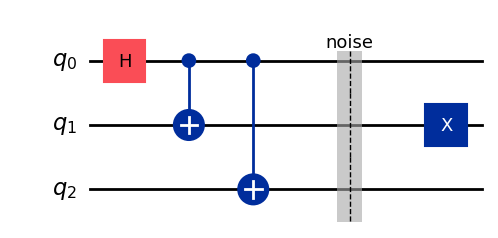

In [5]:
with_error = QuantumCircuit(3)
with_error.h(0)
encode_bit_flip(with_error)
with_error.barrier(label="noise")

# Noise: flip the second physical qubit.
with_error.x(1)

with_error.draw("mpl")

## What Is a Syndrome?

A **syndrome** is information about the error, without revealing whether the data was $|0\rangle$, $|1\rangle$, or a superposition.

First, we undo the two encoding CNOTs. The helper qubits then hold this pattern:

| Situation | q1 | q2 | Meaning |
|---|:---:|:---:|---|
| No error | 0 | 0 | Nothing flipped |
| $X$ on q0 | 1 | 1 | Data qubit flipped |
| $X$ on q1 | 1 | 0 | First helper flipped |
| $X$ on q2 | 0 | 1 | Second helper flipped |

The pattern depends on the **error location**, not on $\alpha$ or $\beta$. That is why error information can be learned without learning the protected quantum state.

In this beginner circuit we keep the syndrome coherent instead of measuring it. A Toffoli (`CCX`) flips q0 only when q1 and q2 are both 1.

In [8]:
def recover_bit_flip(circuit):
    # Decode: move the error information onto q1 and q2.
    circuit.cx(0, 1)
    circuit.cx(0, 2)

    # Syndrome 11 means q0 was flipped, so flip it back.
    circuit.ccx(1, 2, 0)

## Complete Encode-Error-Recover Circuit

Here is the full circuit for an $X$ error on the second physical qubit.

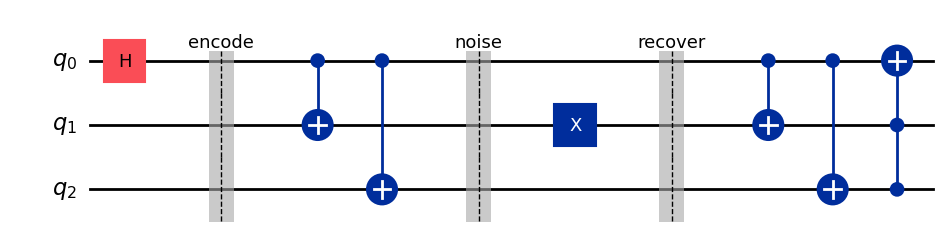

In [9]:
corrected_example = QuantumCircuit(3)
corrected_example.h(0)
corrected_example.barrier(label="encode")
encode_bit_flip(corrected_example)
corrected_example.barrier(label="noise")
corrected_example.x(1)
corrected_example.barrier(label="recover")
recover_bit_flip(corrected_example)

corrected_example.draw("mpl")

## Verify $|+\rangle$ with an Inverse Preparation

Measuring $|+\rangle$ directly gives random 0s and 1s, so that would not prove that we recovered it.

Instead, apply the inverse of its preparation. The Hadamard gate is its own inverse:

$$H|+\rangle=|0\rangle.$$

Therefore, a successful experiment should measure `0` every time in an ideal simulator. This verifies that the relative phase—the coherence—survived.

Verification counts: {'0': 1000}


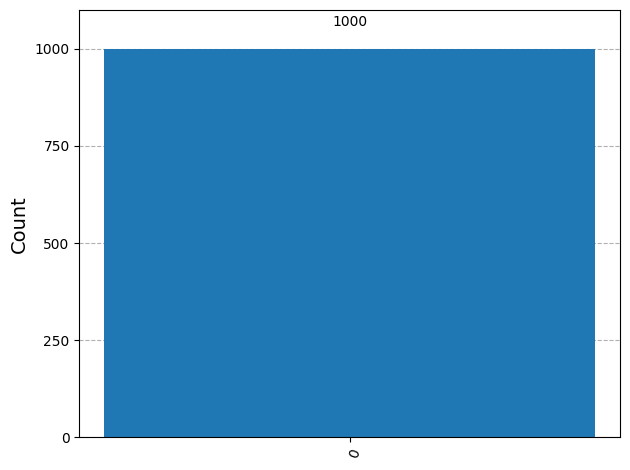

In [13]:
def recover_bit_flip(circuit):
    # Decode: move the error information onto q1 and q2.
    circuit.cx(0, 1)
    circuit.cx(0, 2)

    # Syndrome 11 means q0 was flipped, so flip it back.
    circuit.ccx(1, 2, 0)

simulator = AerSimulator()

plus_check = QuantumCircuit(3, 1)
plus_check.h(0)
encode_bit_flip(plus_check)
plus_check.x(1)
recover_bit_flip(plus_check)

# Undo the |+> preparation before measuring.
plus_check.h(0)
plus_check.measure(0, 0)

compiled = transpile(plus_check, simulator)
counts = simulator.run(compiled, shots=1000).result().get_counts(compiled)

print("Verification counts:", counts)
plot_histogram(counts)

## Test Every Single-Error Location

There is one subtle point: $X|+\rangle=|+\rangle$. The $|+\rangle$ experiment checks that coherence is preserved, but by itself it is not a strong test of bit-flip correction.

For a stronger check, prepare an asymmetric coherent state

$$
|\psi\rangle=\cos(\theta/2)|0\rangle+e^{i\phi}\sin(\theta/2)|1\rangle,
$$

then compare the recovered data qubit with the exact input using **state fidelity**. Fidelity 1 means a perfect match. We test no error and an $X$ error on each of the three physical qubits.

In [11]:
def prepare_arbitrary_state(circuit, theta, phi, qubit=0):
    circuit.ry(theta, qubit)
    circuit.rz(phi, qubit)


def corrected_data_state(theta, phi, error_qubit=None):
    circuit = QuantumCircuit(3)
    prepare_arbitrary_state(circuit, theta, phi)
    encode_bit_flip(circuit)

    if error_qubit is not None:
        circuit.x(error_qubit)

    recover_bit_flip(circuit)

    full_state = Statevector.from_instruction(circuit)

    # Discard q1 and q2 mathematically and keep only data qubit q0.
    return partial_trace(full_state, [1, 2])


theta = 1.1
phi = 0.7

target_circuit = QuantumCircuit(1)
prepare_arbitrary_state(target_circuit, theta, phi)
target_state = Statevector.from_instruction(target_circuit)

tests = [
    ("No error", None),
    ("X on q0", 0),
    ("X on q1", 1),
    ("X on q2", 2),
]

for label, error_qubit in tests:
    recovered_state = corrected_data_state(theta, phi, error_qubit)
    fidelity = state_fidelity(target_state, recovered_state)
    print(f"{label:10s} -> fidelity = {fidelity:.6f}")

No error   -> fidelity = 1.000000
X on q0    -> fidelity = 1.000000
X on q1    -> fidelity = 1.000000
X on q2    -> fidelity = 1.000000


### Expected Result

Every line should report:

```text
fidelity = 1.000000
```

This confirms that the circuit recovers the same arbitrary input state after any **one** physical-qubit bit flip. The helper qubits may retain a syndrome, but the data qubit is restored.

## Exercise: What If Two Qubits Flip?

The three-qubit repetition code uses a quantum version of majority voting. Predict what happens when **two** physical qubits flip, then complete the TODO below.

1. Put two different qubit numbers in `error_pair`, such as `(0, 1)`.
2. Run the cell and inspect the fidelity.
3. Try the other two pairs.
4. Explain why two errors look like the wrong majority.

In [12]:
# Write your code here.
# TODO: Replace the empty tuple with two different qubits, for example (0, 1).
error_pair = ()

student_circuit = QuantumCircuit(3)
prepare_arbitrary_state(student_circuit, theta, phi)
encode_bit_flip(student_circuit)

for qubit in error_pair:
    student_circuit.x(qubit)

recover_bit_flip(student_circuit)
student_full_state = Statevector.from_instruction(student_circuit)
student_data_state = partial_trace(student_full_state, [1, 2])
student_fidelity = state_fidelity(target_state, student_data_state)

print("Error pair:", error_pair)
print(f"Recovered-state fidelity: {student_fidelity:.6f}")

Error pair: ()
Recovered-state fidelity: 1.000000


## What This Code Can and Cannot Correct

This three-qubit repetition code can correct:

- no error
- one $X$ error on q0, q1, **or** q2

It cannot correct:

- two or three simultaneous $X$ errors
- a phase-flip ($Z$) error
- an arbitrary error containing both bit and phase components

A phase error can destroy the relative phase while leaving the 0/1 populations unchanged. That is why measuring only in the computational basis can miss it. The next notebook develops the phase-flip version of the code.

## What We Learned

1. **No cloning:** quantum error correction does not make independent copies of an unknown state.
2. **Encoding:** CNOT gates map $\alpha|0\rangle+\beta|1\rangle$ to $\alpha|000\rangle+\beta|111\rangle$.
3. **Syndrome:** helper-qubit patterns reveal the error location without revealing the protected amplitudes.
4. **Coherent recovery:** two decoding CNOTs and one Toffoli gate restore the data qubit without an intermediate measurement.
5. **Verification:** inverse preparation tests coherence, while state fidelity checks the complete quantum state.
6. **Limit:** this small code corrects at most one bit flip; it is not yet a general quantum error-correcting code.

The central idea is that quantum information can be protected by spreading it across **entangled correlations**, then using the error syndrome to reverse the noise.